# Does the "rounding bottom" really signal accumulation? 🥣
### The saucer base — a beautiful chart shape that, on the tape, predicts nothing special

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Accumulation_signal%3F: Not_supported](https://img.shields.io/badge/Accumulation_signal%3F-Not_supported-8b949e?style=flat-square)

Open any technical-analysis book and you'll meet the **rounding bottom** (a.k.a. the *saucer base*): a long, smooth, U-shaped dip where — the story goes — *smart money* is quietly **accumulating** while everyone else has given up. When price finally curves back up and **breaks out** above the rim, that's your buy signal: the saucer is full, the advance begins.

It's a lovely picture. So we built a **mechanical detector** for it — fit a parabola, demand a real U-shape, a dip in the middle, and a confirmed breakout — and asked the only question that matters: *after a confirmed saucer breakout, does the stock do anything a random day wouldn't?* The honest answer is **no**.

> 📓 **Plain-language layer.** Want the *t*-stats, the base-rate comparison and the placebo test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Two honest caveats up front.** (1) Chart figures are **partly subjective** — we test the closest *mechanical* definition and say so; a human chartist might draw the saucer differently. (2) We use a fixed **30-name** basket (SPY + large-caps still trading today), which carries **survivorship**. House style: [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rounding_bottom import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else None
print("real rounding-bottom cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-01-02', 'end': '2026-06-23', 'years': 22.5, 'n_names': 30, 'fp': '69cb517da40d', 'base_len': 90, 'cost_bps': 5.0, 'h10': (10, 184, 0.53, 0.43, 0.59, 51, 57, 1.42, 1.22, -0.15, 0.569), 'h20': (20, 183, 1.51, 1.41, 1.14, 62, 58, 2.97, 2.72, 0.73, 0.252), 'h60': (60, 181, 4.07, 3.97, 3.31, 65, 63, 4.52, 4.42, 0.84, 0.205), 'rob_bl': [(60, 235, 1.12, 2.5, -0.05, 0.542), (90, 183, 1.51, 2.97, 0.73, 0.252), (120, 141, 0.02, 0.04, -1.8, 0.969)], 'rob_r2': [(0.45, 260, 1.29, 2.91, 0.34, 0.368), (0.55, 183, 1.51, 2.97, 0.73, 0.252), (0.7, 59, 0.87, 1.2, -0.37, 0.603)], 'syn': [(0.0, 185, 1.08, 0.48, 2.48, 1.38, 0.111, 57), (0.1, 186, 5.86, 1.07, 10.87, 8.87, 0.0, 80)]}


real rounding-bottom cache present: True | names: 30


## The answer first

| Question | Answer |
|---|---|
| After a confirmed saucer breakout, does the stock go **up**? | **Yes — but so does everything.** It averages **+1.5% over 20 days** and **+4.1% over 60**. Sounds great… |
| …is that **more** than a random day in the same stock? | **No.** A *random* entry date earns **+1.1% / +3.3%** over the same windows — basically the same. The saucer adds **nothing** over just being long. |
| Could the shape just be **luck**? | **Looks like it.** Shuffle in random entry dates thousands of times and they beat the saucer **~1 in 4** times — nowhere near significant. |
| Is it 'accumulation'? | **Not supported.** The breakout return is indistinguishable from the stock's own upward drift. No special smart-money footprint shows up. |

> The shape is real and pretty. The **edge** is a mirage: the saucer breakout earns exactly what the stock was going to earn anyway.

## 1 · The claim

> *"A rounding bottom is a saucer-shaped base that forms over weeks or months. During the saucer, **strong hands accumulate** while sellers are exhausted. The smooth curve up and the **breakout above the rim** confirm the accumulation phase is over — buy the breakout and ride the new uptrend."*

This is canon. It's in Edwards & Magee's *Technical Analysis of Stock Trends*, in John Murphy, in every charting course. The believer's strongest version isn't "the shape is pretty" — it's that the breakout marks a **regime change** from accumulation to markup, so the forward return after a confirmed breakout should **beat the stock's normal drift**. That's the testable promise.

## 2 · So what?

If true, this would be gold: a *visual* signal, drawable by eye, that flags the start of an advance. You'd scan charts for saucers, buy the breakouts, and beat buy-and-hold.

But there's a trap that snares almost every chart-pattern claim. Stocks **drift up** on average. So *any* rule that buys stocks and holds them will show a positive forward return — that's not evidence the **shape** did anything. The only honest test is: does the saucer breakout beat a **random entry** in the same names over the same horizon? If not, the pattern is just an elaborate way of saying "buy a stock."

## 3 · How would we even know?

We take SPY plus **29 large-caps** (22 years of daily bars) and run a **mechanical** rounding-bottom detector at every bar:

1. **A real U.** Fit a parabola to the last ~90 days of closes; demand it actually curves up (positive curvature) and fits well.
2. **A dip in the middle.** The low point must sit *inside* the window, not at an edge — a saucer, not a slide.
3. **A confirmed breakout.** The close must cross back **above the rim** (the left-edge high) for the first time — the saucer is finished.

Then we enter the **next day's open** (no cheating) and measure the forward 10 / 20 / 60-day return — against the **base rate** (a random day in the same stock) and a **date-shuffle placebo**. **Mirage verdict if** the breakout doesn't beat random entries.

## 4 · The teardown — let's actually look

**First, what does the detector even find?** Here's one real saucer it flagged — the fitted U-shape and the breakout bar. The shape detection works; that was never the question.

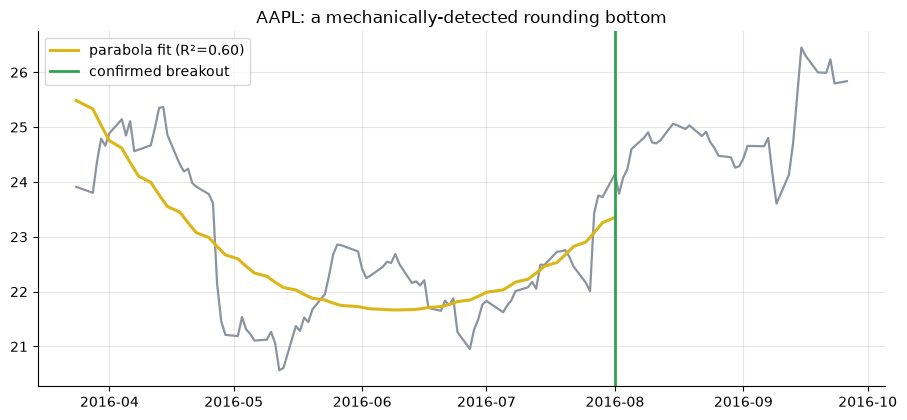

AAPL saucer breakout on 2016-08-01: fit R²=0.60


In [2]:
if HAVE_REAL:
    tk = 'AAPL'
    bars = PANEL[tk]
    bk = st.detect_breakouts(bars, base_len=R['base_len'])
    if len(bk):
        bo = bk.index[len(bk)//2]
        i = bars.index.get_loc(bo)
        w = bars['close'].iloc[i-R['base_len']+1:i+40]
        fig, ax = plt.subplots(figsize=(9.2,4.3))
        ax.plot(w.index, w.values, color=GREY, lw=1.6)
        seg = np.log(bars['close'].iloc[i-R['base_len']+1:i+1].values)
        a,b,d,r2 = st._parabola_fit(seg)
        u = np.arange(len(seg)); fit = np.exp(a*u*u+b*u+d)
        ax.plot(w.index[:len(seg)], fit, color=AMBER, lw=2.2, label=f'parabola fit (R\u00b2={r2:.2f})')
        ax.axvline(bo, color=GREEN, lw=2, label='confirmed breakout')
        ax.set_title(f'{tk}: a mechanically-detected rounding bottom'); ax.legend()
        plt.tight_layout(); plt.show()
        print(f'{tk} saucer breakout on {bo.date()}: fit R\u00b2={r2:.2f}')
else:
    print('(cache absent — detector demo skipped; numbers are frozen in R)')

The detector cleanly finds the figure: a smooth U, a fitted parabola, a breakout. The shape is genuinely *there*. Now the real question — **does it pay?**

**The decisive chart.** Saucer-breakout forward return (green) vs the **base rate** — a random day in the same stocks (grey) — at three horizons. If the pattern means anything, green should tower over grey.

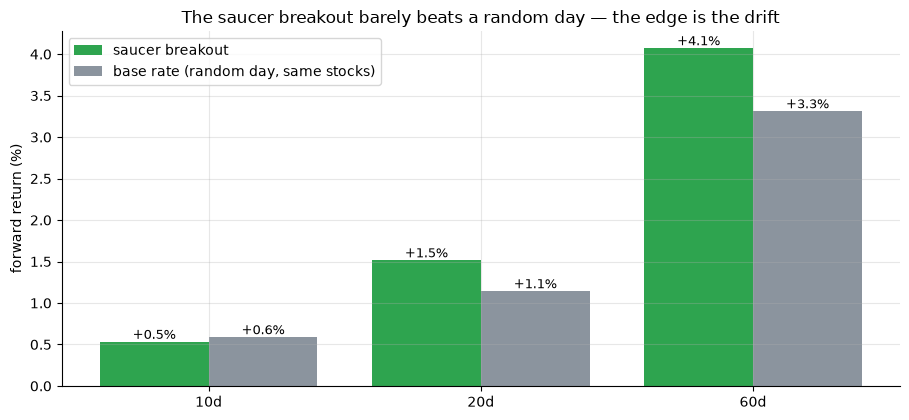

signal: [0.53, 1.51, 4.07]  base: [0.59, 1.14, 3.31]


In [3]:
hs = [10, 20, 60]
if HAVE_REAL:
    sig, base = [], []
    for h in hs:
        r = st.run_experiment(PANEL, base_len=R['base_len'], horizon=h, cost_bps=5.0, placebo=False)
        sig.append(r['gross_mean']*100); base.append(r['base_mean']*100)
else:
    sig = [R['h10'][2], R['h20'][2], R['h60'][2]]
    base = [R['h10'][4], R['h20'][4], R['h60'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.bar(x-.2, sig, .4, color=GREEN, label='saucer breakout')
ax.bar(x+.2, base, .4, color=GREY, label='base rate (random day, same stocks)')
for i,(s,b) in enumerate(zip(sig,base)):
    ax.annotate(f'{s:+.1f}%',(i-.2,s),ha='center',va='bottom',fontsize=9)
    ax.annotate(f'{b:+.1f}%',(i+.2,b),ha='center',va='bottom',fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('forward return (%)')
ax.set_title('The saucer breakout barely beats a random day — the edge is the drift'); ax.legend()
plt.tight_layout(); plt.show()
print('signal:', [round(s,2) for s in sig], ' base:', [round(b,2) for b in base])

There's the whole story. At 20 days the breakout earns **+1.5%** — but a **random day** in the same stocks earns **+1.1%**. At 60 days: **+4.1%** vs **+3.3%**. The bars are almost the same height. The saucer isn't adding an edge; it's just selecting *a moment to be long a stock that was drifting up anyway.*

## 5 · The verdict

- **Signal — None.** The breakout's forward return **does not beat the base rate** (20-day: +1.5% vs +1.1%; difference statistically zero). A date-shuffle placebo says random entries do just as well ~1 in 4 times.
- **Tradability — Mirage.** There's no excess return to trade — the absolute gain is just the market's drift, which you'd capture for free by holding the stock.
- **"Accumulation signal"? — Not supported.** No special smart-money footprint shows up in the forward returns; the breakout looks like any other day in an up-drifting stock.

## 6 · Could you actually trade it?

Short version: **there's nothing to trade.** The saucer breakout's *gross* return is already no better than random; charging even a tiny **5 bps** round-trip cost just nudges an already-zero edge into the red. You'd do as well — and pay no scanning effort — by buying the stock on a coin flip and holding.

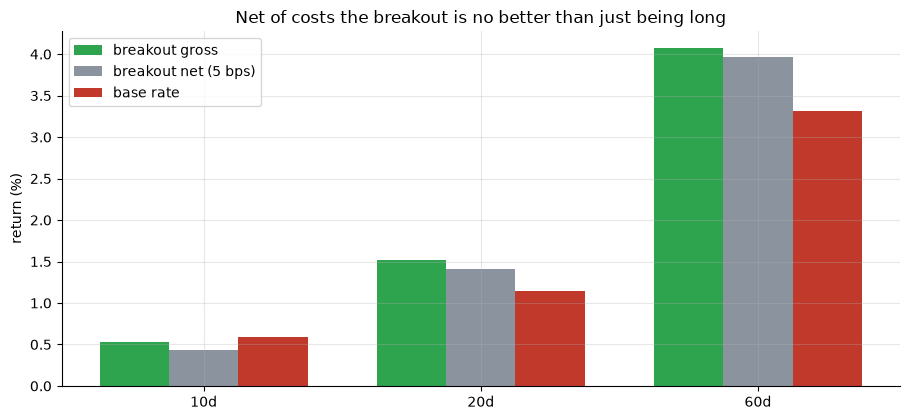

net: [0.43, 1.41, 3.97]  base: [0.59, 1.14, 3.31]


In [4]:
if HAVE_REAL:
    g, nv, bs = [], [], []
    for h in hs:
        r = st.run_experiment(PANEL, base_len=R['base_len'], horizon=h, cost_bps=5.0, placebo=False)
        g.append(r['gross_mean']*100); nv.append(r['net_mean']*100); bs.append(r['base_mean']*100)
else:
    g=[R['h10'][2],R['h20'][2],R['h60'][2]]; nv=[R['h10'][3],R['h20'][3],R['h60'][3]]; bs=[R['h10'][4],R['h20'][4],R['h60'][4]]
x=np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.bar(x-.25,g,.25,color=GREEN,label='breakout gross')
ax.bar(x,nv,.25,color=GREY,label='breakout net (5 bps)')
ax.bar(x+.25,bs,.25,color=RED,label='base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('return (%)')
ax.set_title('Net of costs the breakout is no better than just being long'); ax.legend()
plt.tight_layout(); plt.show()
print('net:', [round(v,2) for v in nv], ' base:', [round(b,2) for b in bs])

> The honest bottom line: a rounding bottom is a **description of the past**, not a **prediction of the future**. By the time the breakout confirms, the easy part — the climb out of the basin — has already happened on the chart.

## 7 · Going further 🚪

- **Subjectivity is the obvious escape hatch.** A believer can always say "that's not how *I'd* draw it." Fair — but a rule you can't write down is a rule you can't test or trade. Tighten or loosen the detector (we vary the window and fit threshold in the quants notebook) and the verdict doesn't budge.
- **Volume confirmation.** Classic lore adds *rising volume on the breakout*. A natural next experiment: condition on a volume surge and re-test — does the base-rate gap open up?
- **Small-caps / longer saucers.** The figure is folklore-strongest in beaten-down small-caps over multi-month bases; re-run there (mind survivorship and costs).

*Think the saucer beats random entries once you add volume? Show the breakout's forward return clearing the **base rate** at t ≥ 2 — then we'll talk.*